In [131]:
import torch
import torchvision
from torch import nn
from torchvision.transforms import v2
from torchvision import tv_tensors
from pathlib import Path
import os
from PIL import Image
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pprint import pprint

In [45]:
dataset_root = Path(os.path.expanduser("~/Developer/Research/datasets/"))
images_df = pd.read_csv(
    dataset_root / "CUB_200_2011" / "images.txt",
    header=None,
    delimiter=" ",
    names=["img_id", "path"],
    usecols=[0, 1],
    index_col=0
)
splits_df = pd.read_csv(
    dataset_root / "CUB_200_2011" / "train_test_split.txt",
    header=None,
    delimiter=" ",
    names=["img_id", "is_train"],
    usecols=[0, 1],
    index_col=0
)
keypoints_df = pd.read_csv(
    dataset_root / "CUB_200_2011" / "parts"/ "part_locs.txt",
    header=None,
    delimiter=" ",
    names=["img_id", "part_id", "x", "y"],
    usecols=[0, 1, 2, 3],
    index_col=0
)
bbox_df = pd.read_csv(
    dataset_root / "CUB_200_2011" / "bounding_boxes.txt",
    header=None,
    delimiter=" ",
    names=["img_id", "x", "y", "w", "h"],
    usecols=[0, 1, 2, 3, 4],
    index_col=0
)
images_df.index = images_df.index - 1
splits_df.index = splits_df.index - 1
keypoints_df.index = keypoints_df.index - 1
bbox_df.index = bbox_df.index - 1
keypoints_df
bbox_df

,x,y,w,h
img_id,,,,
0,60.0,27.0,325.0,304.0
1,139.0,30.0,153.0,264.0
2,14.0,112.0,388.0,186.0
3,112.0,90.0,255.0,242.0
4,70.0,50.0,134.0,303.0
...,...,...,...,...
11783,89.0,95.0,354.0,250.0
11784,157.0,62.0,184.0,219.0
11785,190.0,102.0,198.0,202.0


In [67]:
img_id = 200
keypoints = keypoints_df.loc[
    (keypoints_df.index == img_id) &
    (keypoints_df["x"] != 0) &
    (keypoints_df["y"] != 0)
]
raw_img = Image.open(dataset_root / "CUB_200_2011" / "images" / images_df.iloc[img_id]["path"])
raw_w, raw_h = raw_img.size
object_x, object_y, object_w, object_h = tuple(bbox_df.iloc[img_id][["x", "y", "w", "h"]])
img_keypoints = tv_tensors.KeyPoints(keypoints[["x", "y"]].to_numpy(), canvas_size=(raw_h, raw_w))
img_keypoints_transformed = v2.functional.crop(img_keypoints, top=object_y, left=object_x, height=object_h, width=object_w)

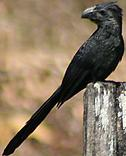

In [66]:
cropped_img = Image.open(dataset_root / "cub200_cropped" / "test_cropped" / images_df.iloc[img_id]["path"])
cropped_img

In [70]:
img_keypoints_transformed.numpy()

array([[ 86.,  41.],
       [ 86.,  13.],
       [114.,  64.],
       [118.,  48.],
       [109.,   5.],
       [100.,   6.],
       [103.,  12.],
       [111.,  26.],
       [101.,  81.],
       [ 99.,  57.],
       [ 33., 122.],
       [ 99.,  24.]])

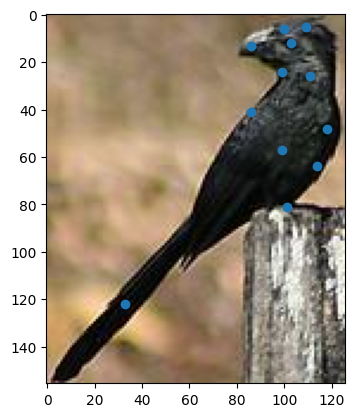

In [76]:
plt.imshow(np.array(cropped_img))
plt.scatter(img_keypoints_transformed.numpy()[:, 0], img_keypoints_transformed.numpy()[:, 1])
plt.show()

In [144]:
from collections import defaultdict
part_name2part_idx = defaultdict(list)
with open(dataset_root / "CUB_200_2011" / "parts" / "parts.txt", "r") as fp:
    parts = [line.split(" ", 1)[1] for line in fp.read().splitlines()]

for i, part_name in enumerate(parts):
    part_name2part_idx[part_name.split(" ")[-1]].append(i)
    parts = set(p.split(" ", 1)[-1] for p in parts)
part_name2part_idx

defaultdict(list,
            {'back': [0],
             'beak': [1],
             'belly': [2],
             'breast': [3],
             'crown': [4],
             'forehead': [5],
             'eye': [6, 10],
             'leg': [7, 11],
             'wing': [8, 12],
             'nape': [9],
             'tail': [13],
             'throat': [14]})

In [153]:
from eval.local_parts import attributes_indexes
from collections import defaultdict

with open(dataset_root / "CUB_200_2011" / "attributes.txt", "r") as fp:
    attributes = fp.read().splitlines()
    attributes = [attributes[i] for i in attributes_indexes]

with open(dataset_root / "CUB_200_2011" / "parts" / "parts.txt", "r") as fp:
    parts = [line.split(" ", 1)[1] for line in fp.read().splitlines()]

attr_id2part_indices = defaultdict(list)
for attr_idx, attr in enumerate(attributes):
    for part in part_name2part_idx:
        if part not in attr:
            continue
        print(attr, "->", part)
        attr_id2part_indices[attr_idx] += part_name2part_idx[part]

11 has_wing_color::brown -> wing
15 has_wing_color::grey -> wing
16 has_wing_color::yellow -> wing
21 has_wing_color::black -> wing
22 has_wing_color::white -> wing
24 has_wing_color::buff -> wing
55 has_breast_pattern::solid -> breast
57 has_breast_pattern::striped -> breast
58 has_breast_pattern::multi-colored -> breast
60 has_back_color::brown -> back
64 has_back_color::grey -> back
65 has_back_color::yellow -> back
70 has_back_color::black -> back
71 has_back_color::white -> back
73 has_back_color::buff -> back
76 has_tail_shape::notched_tail -> tail
81 has_upper_tail_color::brown -> tail
85 has_upper_tail_color::grey -> tail
91 has_upper_tail_color::black -> tail
92 has_upper_tail_color::white -> tail
94 has_upper_tail_color::buff -> tail
100 has_head_pattern::eyebrow -> eye
107 has_breast_color::brown -> breast
111 has_breast_color::grey -> breast
112 has_breast_color::yellow -> breast
117 has_breast_color::black -> breast
118 has_breast_color::white -> breast
120 has_breast_colo